# Data Loading & Overview

**Goal**: Before we do ANY analysis, we need to understand *what* we have. This is called **data profiling** — it answers:
- What files do we have? What shape/size?
- What do the columns mean?
- Are there missing values?
- How balanced are our classes (Normal vs. Anomaly)?


## Data Importing

In [1]:
import pandas as pd
import numpy as np
import os
# This makes plots appear directly in the notebook
import matplotlib.pyplot as plt
import seaborn as sns
# Set visual style for all plots in this notebook
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)  # Default figure size


In [ ]:
DATA_DIR = "../../preprocessed"  
RAW_LOG  = "../../HDFS.log"

In [ ]:



labels_df = pd.read_csv(os.path.join(DATA_DIR, "anomaly_label.csv"))


templates_df = pd.read_csv(os.path.join(DATA_DIR, "HDFS.log_templates.csv"))


matrix_df = pd.read_csv(os.path.join(DATA_DIR, "Event_occurrence_matrix.csv"))



traces_df = pd.read_csv(os.path.join(DATA_DIR, "Event_traces.csv"))

print(" All datasets loaded!")
print(f"   labels:    {labels_df.shape[0]:>10,} rows × {labels_df.shape[1]} cols")
print(f"   templates: {templates_df.shape[0]:>10,} rows × {templates_df.shape[1]} cols")
print(f"   matrix:    {matrix_df.shape[0]:>10,} rows × {matrix_df.shape[1]} cols")
print(f"   traces:    {traces_df.shape[0]:>10,} rows × {traces_df.shape[1]} cols")


✅ All datasets loaded!
   labels:       575,061 rows × 2 cols
   templates:         29 rows × 2 cols
   matrix:       575,061 rows × 32 cols
   traces:       575,061 rows × 6 cols


In [ ]:
# the templates to understand the events identity: 
templates_df.head(10)  # Show the first 10 rows of the templates DataFrame

,EventId,EventTemplate
0,E1,[*]Adding an already existing block[*]
1,E2,[*]Verification succeeded for[*]
2,E3,[*]Served block[*]to[*]
3,E4,[*]Got exception while serving[*]to[*]
4,E5,[*]Receiving block[*]src:[*]dest:[*]
5,E6,[*]Received block[*]src:[*]dest:[*]of size[*]
6,E7,[*]writeBlock[*]received exception[*]
7,E8,[*]PacketResponder[*]for block[*]Interrupted[*]
8,E9,[*]Received block[*]of size[*]from[*]
9,E10,[*]PacketResponder[*]Exception[*]


In [ ]:

event_categories = {
    "Block Lifecycle": ["E22", "E21", "E23", "E24"],  # allocate, delete, invalidate, remove
    "Data Transfer":   ["E5", "E6", "E16", "E18"],    # receiving, received, transmitted, transfer thread
    "Serving/Reading": ["E2", "E3", "E4"],             # verification, served, exception serving
    "Replication":     ["E25", "E26", "E27", "E28"],   # ask to replicate, addStoredBlock, redundant, no file
    "Packet Response": ["E9", "E11", "E8", "E10"],     # received size, terminating, interrupted, exception
    "Write Errors":    ["E7", "E12"],                  # writeBlock exception, write to mirror exception
    "Block Errors":    ["E14", "E17", "E20", "E29"],   # receiveBlock exception, transfer fail, delete error, timeout
    "Other":           ["E1", "E13", "E15", "E19"],    # duplicate block, empty packet, offset change, reopen
}
# Print it nicely
for category, events in event_categories.items():
    print(f"\n{'─'*50}")
    print(f"  {category}")
    print(f"{'─'*50}")
    for eid in events:
        template = templates_df[templates_df['EventId'] == eid]['EventTemplate'].values
        if len(template) > 0:
            print(f"    {eid:>4s} │ {template[0]}")


──────────────────────────────────────────────────
  Block Lifecycle
──────────────────────────────────────────────────
     E22 │ [*]BLOCK* NameSystem[*]allocateBlock:[*]
     E21 │ [*]Deleting block[*]file[*]
     E23 │ [*]BLOCK* NameSystem[*]delete:[*]is added to invalidSet of[*]
     E24 │ [*]BLOCK* Removing block[*]from neededReplications as it does not belong to any file[*]

──────────────────────────────────────────────────
  Data Transfer
──────────────────────────────────────────────────
      E5 │ [*]Receiving block[*]src:[*]dest:[*]
      E6 │ [*]Received block[*]src:[*]dest:[*]of size[*]
     E16 │ [*]:Transmitted block[*]to[*]
     E18 │ [*]Starting thread to transfer block[*]to[*]

──────────────────────────────────────────────────
  Serving/Reading
──────────────────────────────────────────────────
      E2 │ [*]Verification succeeded for[*]
      E3 │ [*]Served block[*]to[*]
      E4 │ [*]Got exception while serving[*]to[*]

────────────────────────────────────────────

## Data Profiling : 

In [ ]:

def profile_dataframe(df, name):
    """Print a concise profile of a DataFrame."""
    print(f"\n{'═'*60}")
    print(f"  {name}")
    print(f"{'═'*60}")
    print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Memory: {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")
    print(f"\n  {'Column':<20} {'Dtype':<15} {'Non-Null':>10} {'Null':>8} {'Unique':>10}")
    print(f"  {'─'*63}")
    for col in df.columns:
        non_null = df[col].notna().sum()
        null_count = df[col].isna().sum()
        unique = df[col].nunique()
        print(f"  {col:<20} {str(df[col].dtype):<15} {non_null:>10,} {null_count:>8,} {unique:>10,}")
profile_dataframe(labels_df, "ANOMALY LABELS")
profile_dataframe(templates_df, "EVENT TEMPLATES")
profile_dataframe(matrix_df, "EVENT OCCURRENCE MATRIX")
profile_dataframe(traces_df, "EVENT TRACES")


════════════════════════════════════════════════════════════
  ANOMALY LABELS
════════════════════════════════════════════════════════════
  Shape: 575,061 rows × 2 columns
  Memory: 69.9 MB

  Column               Dtype             Non-Null     Null     Unique
  ───────────────────────────────────────────────────────────────
  BlockId              str                575,061        0    575,061
  Label                str                575,061        0          2

════════════════════════════════════════════════════════════
  LOG TEMPLATES
════════════════════════════════════════════════════════════
  Shape: 29 rows × 2 columns
  Memory: 0.0 MB

  Column               Dtype             Non-Null     Null     Unique
  ───────────────────────────────────────────────────────────────
  EventId              str                     29        0         29
  EventTemplate        str                     29        0         29

════════════════════════════════════════════════════════════
  EVENT

## Class Balance Checking :
check if we have to perform any class balancing techniques to avoid bias in the model.

Class Distribution:
  Normal:     558,223  (97.07%)
  Anomaly:     16,838  (2.93%)
  Ratio:   1 anomaly per 33.2 normal blocks


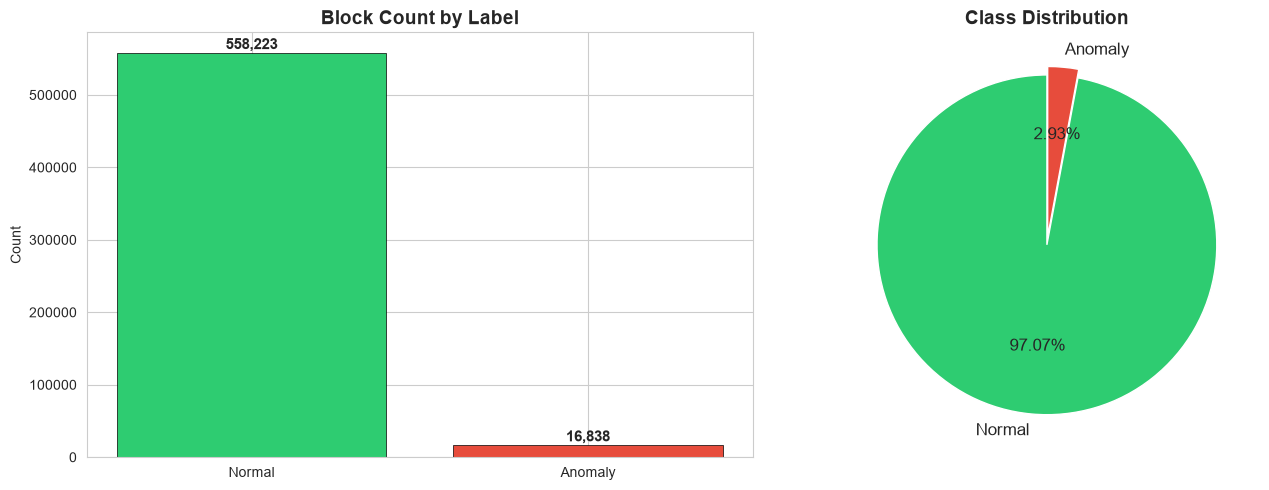


📊 Chart saved to outputs/class_distribution.png


In [ ]:
# Class Balance Analysis:

class_counts = labels_df['Label'].value_counts()
class_pcts = labels_df['Label'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"  Normal:  {class_counts['Normal']:>10,}  ({class_pcts['Normal']:.2f}%)")
print(f"  Anomaly: {class_counts['Anomaly']:>10,}  ({class_pcts['Anomaly']:.2f}%)")
print(f"  Ratio:   1 anomaly per {class_counts['Normal']/class_counts['Anomaly']:.1f} normal blocks")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']  
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Block Count by Label', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (label, count) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, count + 5000, f'{count:,}', ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.2f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12},
            explode=(0, 0.05))  # Slightly explode the anomaly slice
axes[1].set_title('Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Chart saved to outputs/class_distribution.png")


In [ ]:
labels_df.head(10)  

,BlockId,Label
0,blk_-1608999687919862906,Normal
1,blk_7503483334202473044,Normal
2,blk_-3544583377289625738,Anomaly
3,blk_-9073992586687739851,Normal
4,blk_7854771516489510256,Normal
5,blk_1717858812220360316,Normal
6,blk_-2519617320378473615,Normal
7,blk_7063315473424667801,Normal
8,blk_8586544123689943463,Normal
9,blk_2765344736980045501,Normal


In [ ]:
matrix_df.head(10)  

,BlockId,Label,Type,E1,E2,E3,E4,E5,E6,E7,...,E20,E21,E22,E23,E24,E25,E26,E27,E28,E29
0,blk_-1608999687919862906,Success,NaN,0,0,203,0,10,7,0,...,0,10,1,10,0,4,10,0,0,0
1,blk_7503483334202473044,Success,NaN,0,2,1,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
2,blk_-3544583377289625738,Fail,21.0,0,0,203,0,3,0,0,...,1,3,1,3,0,0,3,0,0,0
3,blk_-9073992586687739851,Success,NaN,0,3,0,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
4,blk_7854771516489510256,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0
5,blk_1717858812220360316,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0
6,blk_-2519617320378473615,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0
7,blk_7063315473424667801,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0
8,blk_8586544123689943463,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0
9,blk_2765344736980045501,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0


In [ ]:

event_cols = [col for col in matrix_df.columns if col.startswith('E')]
print(f"Number of event features: {len(event_cols)}")
print(f"\nBasic statistics across all blocks:\n")
# .describe() gives count, mean, std, min, 25%, 50%, 75%, max
stats = matrix_df[event_cols].describe().T
stats = stats[['mean', 'std', 'min', '50%', 'max']]
stats.columns = ['Mean', 'Std Dev', 'Min', 'Median', 'Max']

print(stats.sort_values('Mean', ascending=False).to_string())

Number of event features: 29

Basic statistics across all blocks:

         Mean   Std Dev  Min  Median    Max
E5   2.996607  0.220913  1.0     3.0   13.0
E26  2.990537  0.408638  0.0     3.0   13.0
E11  2.967823  0.309920  0.0     3.0    6.0
E9   2.967536  0.310178  0.0     3.0    3.0
E21  2.438084  1.184490  0.0     3.0   13.0
E23  2.427871  1.182648  0.0     3.0   10.0
E22  1.000000  0.000000  1.0     1.0    1.0
E3   0.745531  2.517178  0.0     0.0  203.0
E4   0.619425  1.604554  0.0     0.0   41.0
E2   0.208736  0.580644  0.0     0.0    4.0
E6   0.012341  0.146923  0.0     0.0   10.0
E18  0.012176  0.140481  0.0     0.0    5.0
E25  0.012176  0.140481  0.0     0.0    5.0
E16  0.012063  0.139491  0.0     0.0    5.0
E20  0.009642  0.101269  0.0     0.0    3.0
E7   0.005940  0.080642  0.0     0.0    5.0
E13  0.002546  0.087355  0.0     0.0    3.0
E28  0.002240  0.048865  0.0     0.0    4.0
E27  0.001695  0.041183  0.0     0.0    2.0
E14  0.000270  0.027502  0.0     0.0    5.0
E10  0.00

In [ ]:
print("First 10 lines of HDFS.log:\n")
with open(RAW_LOG, 'r') as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        print(f"  Line {i+1}: {line.strip()}")

print("\nCounting total lines...")
line_count = sum(1 for _ in open(RAW_LOG, 'r'))
print(f"  Total log lines: {line_count:,}")

First 10 lines of HDFS.log:

  Line 1: 081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010
  Line 2: 081109 203518 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /mnt/hadoop/mapred/system/job_200811092030_0001/job.jar. blk_-1608999687919862906
  Line 3: 081109 203519 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.10.6:40524 dest: /10.250.10.6:50010
  Line 4: 081109 203519 145 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.14.224:42420 dest: /10.250.14.224:50010
  Line 5: 081109 203519 145 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_-1608999687919862906 terminating
  Line 6: 081109 203519 145 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_-1608999687919862906 terminating
  Line 7: 081109 203519 145 INFO dfs.DataNode$PacketResponder: Received block blk_-160899968791